In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from mcbuild_generator.constants.paths import *

sns.set_theme()

## Global

In [2]:
filenames = os.listdir(os.path.join("..", BUILDS_DIR))

print(f"Total Files: {len(filenames)}")

extensions = [f.split(".")[-1] for f in filenames]

counts = Counter(extensions)
print(counts)

Total Files: 28236
Counter({'schem': 28235, 'gitkeep': 1})


## Schem Files

### Metadata

In [3]:
metadata_df = pd.read_csv(os.path.join("..", BUILDS_METADATA_CSV))

#### Outliers

In [4]:
COLUMN = "palettemax"
FILTER_MODE = 'MAD'  # MAD or IQR

In [5]:
def remove_outliers_iqr(col):
    Q1 = metadata_df[col].quantile(0.25)
    Q3 = metadata_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return metadata_df[(metadata_df[col] >= lower) & (metadata_df[col] <= upper)]


def remove_outliers_mad(col):
    median = metadata_df[col].median()
    MAD = (metadata_df[col] - median).abs().median()

    # approximate standard deviation scaling
    threshold = 3 * 1.4826 * MAD
    return metadata_df[(metadata_df[col] - median).abs() <= threshold]

Original
count : 28235


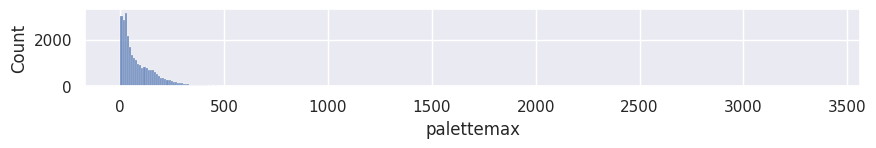

Filtered
count : 26205


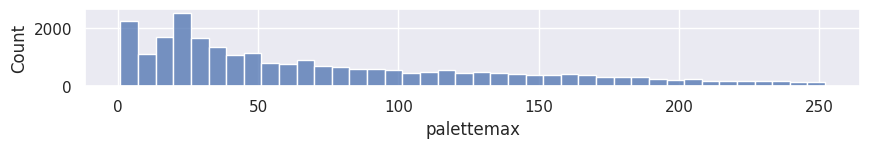

In [6]:
if FILTER_MODE == 'IQR':
    metadata_df_filtered = remove_outliers_iqr(COLUMN)
elif FILTER_MODE == 'MAD':
    metadata_df_filtered = remove_outliers_mad(COLUMN)

print('Original')
print(f"count : {len(metadata_df)}")
plt.figure(figsize=(10, 1))
sns.histplot(metadata_df, x=COLUMN)
plt.show()

print('Filtered')
print(f"count : {len(metadata_df_filtered)}")
plt.figure(figsize=(10, 1))
sns.histplot(metadata_df_filtered, x=COLUMN)
plt.show()

### Blocks

In [7]:
usedblocks_df = pd.read_csv(os.path.join("..", BLOCKS_COUNT_CSV))
print(usedblocks_df.head(1))
print(len(usedblocks_df))

           block     base_block  build_count  block_count
0  minecraft:air  minecraft:air        19716   6529601670
8077


In [8]:
# compute variant_proportion

usedblocks_df['variant_prop_build'] = (
    usedblocks_df['build_count'] /
    usedblocks_df.groupby('base_block')['build_count'].transform('sum')
)
usedblocks_df['variant_prop_block'] = (
    usedblocks_df['block_count']
    / usedblocks_df.groupby('base_block')['block_count'].transform('sum')
    #* usedblocks_df.groupby('base_block')['block'].transform('count')
)

Block Variant (build-wise)


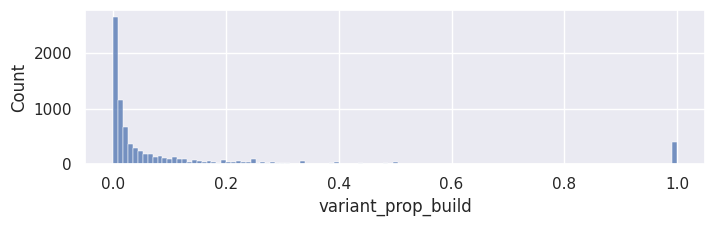

Block Variant (block-wise)


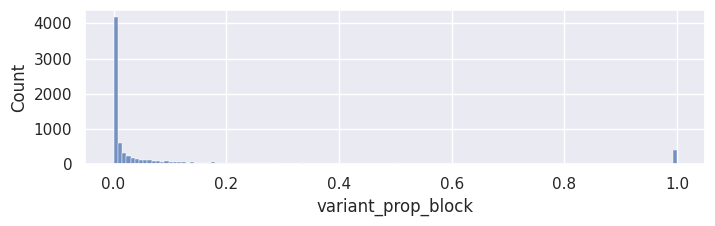

In [9]:
# block variant proportion (build-wise)
print('Block Variant (build-wise)')
plt.figure(figsize=(8,2))
sns.histplot(usedblocks_df, x='variant_prop_build')
plt.show()

# block variant proportion (block-wise)
print('Block Variant (block-wise)')
plt.figure(figsize=(8,2))
sns.histplot(usedblocks_df, x='variant_prop_block')
plt.show()

In [10]:
THRESHOLD = 0.05
PROP_SCALE = 'block' # block or build

most_common_map = (
    usedblocks_df.loc[
        usedblocks_df.groupby('base_block')[f'variant_prop_{PROP_SCALE}'].idxmax()
    ]
    .set_index('base_block')['block']
)

usedblocks_df['new_block'] = usedblocks_df['block']

mask = usedblocks_df[f'variant_prop_{PROP_SCALE}'] < THRESHOLD
print(f'rare blocks count (<{THRESHOLD}): {mask.sum()}')
# replace rare blocks by most common
usedblocks_df.loc[mask, 'new_block'] = (
    usedblocks_df.loc[mask, 'base_block'].map(most_common_map)
)

rare blocks count (<0.05): 5684


In [11]:
rare_blocks = usedblocks_df[usedblocks_df[f'variant_prop_{PROP_SCALE}'] < 0.1]
print(rare_blocks['block'])

10                               minecraft:water[level=8]
13                  minecraft:rail[shape=ascending_south]
21      minecraft:spruce_fence_gate[facing=east,open=F...
25      minecraft:spruce_fence_gate[facing=north,open=...
28                              minecraft:oak_log[axis=x]
                              ...                        
8072                  minecraft:brown_banner[rotation=10]
8073                  minecraft:brown_banner[rotation=14]
8074    minecraft:brown_stained_glass_pane[east=false,...
8075                   minecraft:brown_banner[rotation=1]
8076    minecraft:brown_stained_glass_pane[east=false,...
Name: block, Length: 6300, dtype: str
